In [4]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_cafe_sales.csv to cleaned_cafe_sales.csv


In [5]:
import pandas as pd

df = pd.read_csv('cleaned_cafe_sales.csv')
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

plt.style.use('ggplot')

In [7]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_cafe_sales.csv to cleaned_cafe_sales (1).csv


In [8]:
df = pd.read_csv('cleaned_cafe_sales.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [9]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              10000 non-null  object 
 2   Quantity          10000 non-null  float64
 3   Price Per Unit    10000 non-null  float64
 4   Total Spent       10000 non-null  float64
 5   Payment Method    10000 non-null  object 
 6   Location          10000 non-null  object 
 7   Transaction Date  10000 non-null  object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB
None

Missing Values:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

Summary Statistics:
           Quantity  Price Per Unit   Total Spent
count  10000.000000     10000.00000  10000.000000
mean       3.027100         2.95265  

In [10]:
print("Total Transactions:", len(df))

print("Average Sales:", df['Total Spent'].mean())

print("Maximum Sale:", df['Total Spent'].max())

print("Minimum Sale:", df['Total Spent'].min())

Total Transactions: 10000
Average Sales: 8.93075
Maximum Sale: 25.0
Minimum Sale: 1.0


Item
Juice       2140
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64


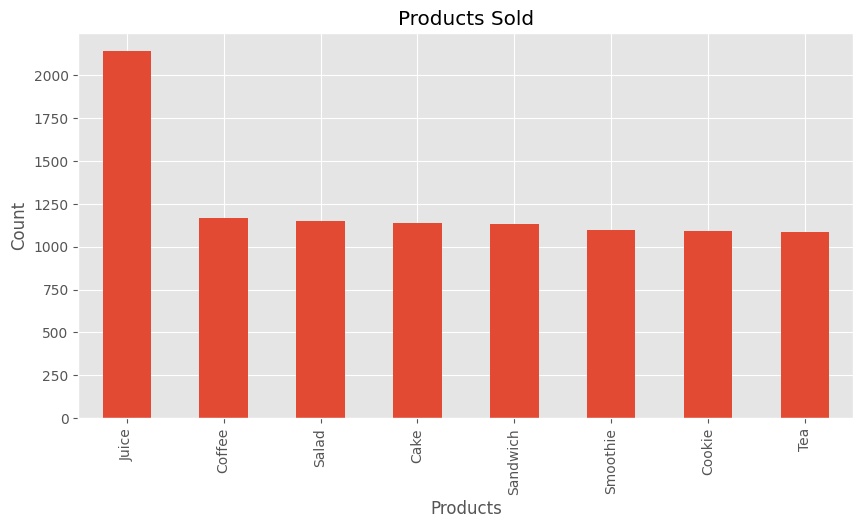

In [11]:
top_products = df['Item'].value_counts()

print(top_products)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Products Sold")
plt.xlabel("Products")
plt.ylabel("Count")
plt.show()

Payment Method
Digital Wallet    5469
Credit Card       2273
Cash              2258
Name: count, dtype: int64


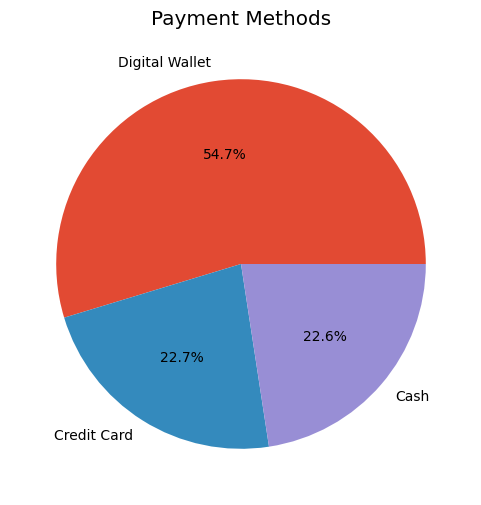

In [12]:
payment = df['Payment Method'].value_counts()

print(payment)

plt.figure(figsize=(6,6))
payment.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("Payment Methods")
plt.show()

Item
Juice       19079.5
Salad       17365.0
Sandwich    13751.0
Smoothie    13362.0
Cake        10413.0
Coffee       7107.0
Tea          4974.0
Cookie       3256.0
Name: Total Spent, dtype: float64


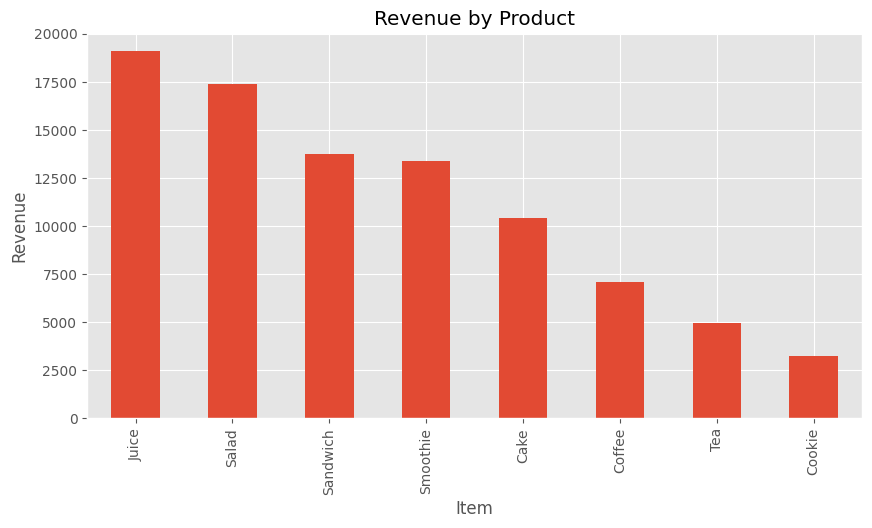

In [13]:
product_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)

print(product_revenue)

plt.figure(figsize=(10,5))
product_revenue.plot(kind='bar')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.show()

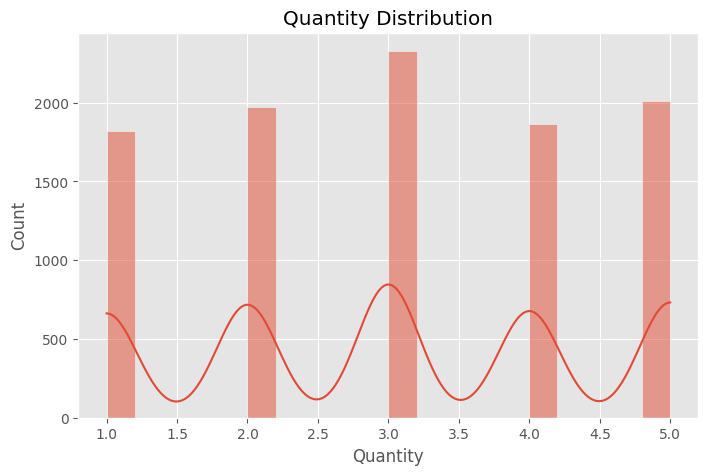

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['Quantity'], bins=20, kde=True)

plt.title("Quantity Distribution")
plt.show()

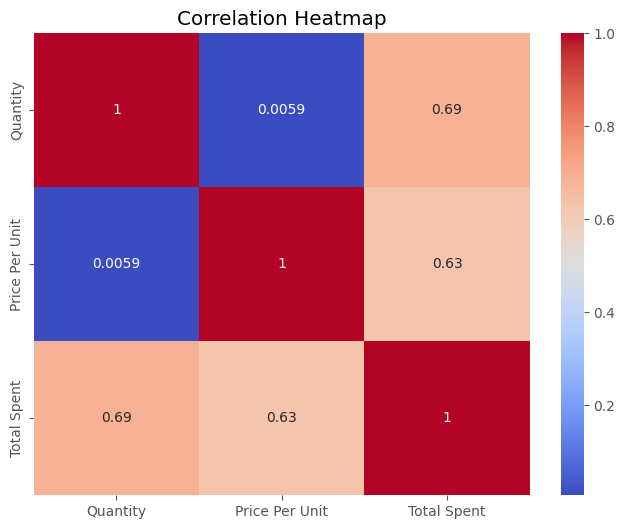

In [15]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

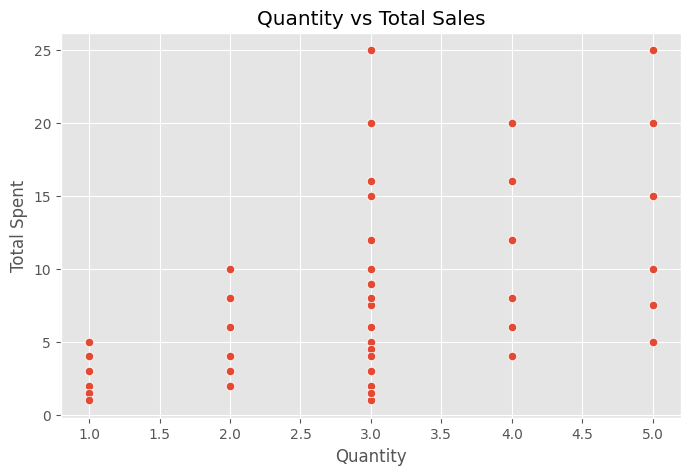

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Quantity'],
    y=df['Total Spent']
)

plt.title("Quantity vs Total Sales")
plt.show()

In [17]:
conn = sqlite3.connect('cafe_sales.db')

df.to_sql(
    'sales',
    conn,
    if_exists='replace',
    index=False
)

print("Database Created")

Database Created


In [18]:
query = """
SELECT Item,
SUM([Total Spent]) AS Revenue
FROM sales
GROUP BY Item
ORDER BY Revenue DESC
LIMIT 5;
"""

pd.read_sql(query, conn)

,Item,Revenue
0,Juice,19079.5
1,Salad,17365.0
2,Sandwich,13751.0
3,Smoothie,13362.0
4,Cake,10413.0


In [19]:
query = """
SELECT [Payment Method],
SUM([Total Spent]) AS Revenue
FROM sales
GROUP BY [Payment Method]
ORDER BY Revenue DESC;
"""

pd.read_sql(query, conn)

,Payment Method,Revenue
0,Digital Wallet,48355.0
1,Credit Card,20493.0
2,Cash,20459.5


In [20]:
query = """
SELECT AVG([Total Spent]) AS Avg_Order_Value
FROM sales;
"""

pd.read_sql(query, conn)

,Avg_Order_Value
0,8.93075


In [21]:
query = """
SELECT Item,
COUNT(*) AS Orders
FROM sales
GROUP BY Item
ORDER BY Orders DESC;
"""

pd.read_sql(query, conn)

,Item,Orders
0,Juice,2140
1,Coffee,1165
2,Salad,1148
3,Cake,1139
4,Sandwich,1131
5,Smoothie,1096
6,Cookie,1092
7,Tea,1089


In [22]:
print("BUSINESS INSIGHTS")

print("\n1. Top Revenue Product:")
print(product_revenue.idxmax())

print("\n2. Most Preferred Payment Method:")
print(payment.idxmax())

print("\n3. Average Customer Spending:")
print(round(df['Total Spent'].mean(),2))

print("\n4. Total Revenue:")
print(round(df['Total Spent'].sum(),2))

BUSINESS INSIGHTS

1. Top Revenue Product:
Juice

2. Most Preferred Payment Method:
Digital Wallet

3. Average Customer Spending:
8.93

4. Total Revenue:
89307.5


In [23]:
df.describe().to_csv('EDA_Report.csv')

print("EDA Report Saved")

EDA Report Saved
